# Data Audit and Cleaning

## Purpose

The purpose of this notebook is to inspect, validate and clean the Online Retail II dataset before conducting customer-level statistical analysis and predictive modelling. The original dataset contains more than one million transaction-line records from a UK-based non-store retailer between December 2009 and December 2011.

Each row represents a product included in an invoice rather than a complete customer order. Consequently, data-quality problems at the transaction level must be addressed before invoices can be aggregated into customer-level features.

The audit focused on identifying missing values, duplicated records, cancellations, returns, invalid prices, invalid quantities, inconsistent data types and extreme observations.

## Dataset Integration

The Excel workbook contains two worksheets:

* Year 2009–2010
* Year 2010–2011

Both worksheets were loaded and combined into a single dataset. A source-period variable was initially included to identify the worksheet from which each transaction originated.

An important issue was identified during the audit: the worksheets overlap between 1 December and 9 December 2010. This caused 1,088 invoices, containing 22,523 transaction rows, to appear in both worksheets.

These duplicated records were removed by comparing the transaction variables while excluding the worksheet source-period label. This prevented the overlapping transactions from being counted twice.

## Data-Quality Assessment

The initial data audit examined:

* Number of rows and columns
* Dataset date range
* Data types
* Missing values
* Unique customers
* Unique invoices
* Unique products
* Countries represented
* Exact and cross-sheet duplicates
* Cancelled invoices
* Negative quantities
* Zero or negative prices
* Extreme transaction values

Transaction value was calculated as:

$$
\text{Transaction Value}
=
\text{Quantity}\times\text{Unit Price}
$$

This calculation was used to identify unusual financial records and distinguish positive purchases from returns or cancellations.

## Missing Customer Identifiers

Approximately 22% of the transaction records did not contain a Customer ID. A Customer ID is essential for connecting purchases to a particular customer and calculating recency, frequency, monetary value, repeat purchasing and future customer revenue.

The missing Customer IDs could not be reliably inferred from product, country, purchase date or transaction value. Assigning artificial identifiers would create fabricated customer histories. Therefore, records without a Customer ID were excluded from customer-level analysis and predictive modelling.

This exclusion introduces a potential limitation. Transactions without Customer IDs may represent guest, anonymous or one-time customers. Therefore, the final customer-level dataset may represent identifiable or registered customers more strongly than the retailer’s complete customer population.

## Duplicate Records

Exact duplicate transaction rows were identified and removed. Cross-sheet duplicates caused by the overlapping worksheet dates were also removed.

Rows were not classified as duplicates merely because they contained the same invoice number and product code. A record was removed only when its relevant transaction fields were duplicated, since legitimate invoices can contain multiple products or repeated product entries.

## Data-Type Standardization

The following variables were standardized:

* Invoice numbers were converted into cleaned text values.
* Stock codes were converted into cleaned text values.
* Invoice dates were converted into datetime values.
* Quantities were converted into numerical values.
* Unit prices were converted into numerical values.
* Customer IDs were converted into consistent identifier strings.

Customer IDs were treated as identifiers rather than numerical measurements because arithmetic operations on customer numbers would not have a meaningful interpretation.

## Purchases, Returns and Cancellations

Invoices beginning with the letter `C` were identified as cancellations. Negative quantities were also treated as indicators of returned or cancelled products.

The cleaned customer transactions were separated into two datasets.

### Valid Purchases

A transaction was classified as a valid positive purchase when:

* A Customer ID was available.
* The invoice was not marked as a cancellation.
* Quantity was greater than zero.
* Unit price was greater than zero.
* Invoice date was valid.

Revenue for a valid purchase was calculated as:

$$
\text{Revenue}
=
\text{Quantity}\times\text{Unit Price}
$$

This dataset was used to construct customer purchasing characteristics, including recency, frequency, monetary value, order value and product diversity.

### Returns and Cancellations

Returns and cancellations were stored separately instead of being discarded. Return value was calculated as:

$$
\text{Return Value}
=
|\text{Quantity}|\times\text{Unit Price}
$$

Keeping returns separately made it possible to construct customer-level variables such as return frequency, return value and return rate.

## Zero and Negative Values

Transactions with zero or negative unit prices were excluded from monetary-value calculations because they did not represent standard positive sales. These records may correspond to administrative adjustments, free items, corrections or incomplete entries.

Negative quantities were not converted into positive purchases because doing so would incorrectly increase customer revenue. They were retained in the separate returns and cancellations dataset.

## Outlier Treatment

The dataset contained exceptionally large quantities, order values and customer monetary values. These observations were not automatically removed because the retailer served wholesale customers, and large transactions could therefore represent legitimate business activity.

Outliers were retained unless they were associated with an identifiable data-quality problem. Their influence was later managed using:

* Logarithmic transformations
* Robust descriptive statistics
* Median-based comparisons
* Robust statistical tests
* Appropriate generalized linear models

This approach avoids removing potentially valuable high-spending customers while reducing their influence on statistical modelling.

## Final Cleaned Data

The cleaning process produced two principal datasets:

1. A positive-purchase dataset containing valid customer purchases.
2. A returns dataset containing customer cancellations and returned products.

The cleaned datasets were saved separately to ensure that the subsequent customer feature-engineering process could distinguish purchasing behaviour from return behaviour.

The original raw dataset was preserved without modification, allowing the cleaning process to remain reproducible and auditable.

## Data-Cleaning Limitations

The principal limitations of the cleaning process are:

* Transactions without Customer IDs cannot contribute to customer-level analysis.
* Excluding unidentified transactions may create selection bias.
* The dataset does not explain the operational reasons for every cancellation, zero price or unusual stock code.
* Some extreme transactions may represent wholesalers rather than errors.
* The dataset contains revenue information but does not include profit margins, acquisition costs or customer service costs.

Despite these limitations, the cleaned data retains a sufficiently large number of identifiable customers and transactions for descriptive analysis, statistical inference, repeat-purchase prediction and revenue-based


In [2]:
!pip install openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

file_path = "/content/drive/MyDrive/Data/Raw/online_retail_II.xlsx"

year1_raw = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

year2_raw = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

print("Year 1 shape:", year1_raw.shape)
print("Year 2 shape:", year2_raw.shape)

Year 1 shape: (525461, 8)
Year 2 shape: (541910, 8)


In [4]:
year1_raw["SourcePeriod"] = "2009-2010"
year2_raw["SourcePeriod"] = "2010-2011"

df_raw = pd.concat(
    [year1_raw, year2_raw],
    ignore_index=True
)

print("Combined shape:", df_raw.shape)
df_raw.head()

Combined shape: (1067371, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourcePeriod
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010


In [5]:
df_raw = df_raw.rename(columns={
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID"
})

print(df_raw.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'SourcePeriod']


In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   InvoiceNo     1067371 non-null  object        
 1   StockCode     1067371 non-null  object        
 2   Description   1062989 non-null  object        
 3   Quantity      1067371 non-null  int64         
 4   InvoiceDate   1067371 non-null  datetime64[ns]
 5   UnitPrice     1067371 non-null  float64       
 6   CustomerID    824364 non-null   float64       
 7   Country       1067371 non-null  object        
 8   SourcePeriod  1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


In [7]:
print("Number of rows:", len(df_raw))
print("Number of columns:", df_raw.shape[1])

print("\nDate range:")
print(df_raw["InvoiceDate"].min())
print(df_raw["InvoiceDate"].max())

print("\nUnique values:")
print("Customers:", df_raw["CustomerID"].nunique())
print("Invoices:", df_raw["InvoiceNo"].nunique())
print("Products:", df_raw["StockCode"].nunique())
print("Countries:", df_raw["Country"].nunique())

Number of rows: 1067371
Number of columns: 9

Date range:
2009-12-01 07:45:00
2011-12-09 12:50:00

Unique values:
Customers: 5942
Invoices: 53628
Products: 5305
Countries: 43


In [8]:
missing_summary = pd.DataFrame({
    "Missing_Count": df_raw.isna().sum(),
    "Missing_Percentage": df_raw.isna().mean() * 100
}).sort_values("Missing_Percentage", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
CustomerID,243007,22.766873
Description,4382,0.410541
InvoiceNo,0,0.000000
Quantity,0,0.000000
StockCode,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000
SourcePeriod,0,0.000000


In [9]:
df_raw["IsCancellation"] = (
    df_raw["InvoiceNo"]
    .astype(str)
    .str.upper()
    .str.startswith("C")
)

quality_counts = {
    "Total rows": len(df_raw),
    "Missing CustomerID": df_raw["CustomerID"].isna().sum(),
    "Missing Description": df_raw["Description"].isna().sum(),
    "Cancellation rows": df_raw["IsCancellation"].sum(),
    "Negative quantities": (df_raw["Quantity"] < 0).sum(),
    "Zero quantities": (df_raw["Quantity"] == 0).sum(),
    "Negative prices": (df_raw["UnitPrice"] < 0).sum(),
    "Zero prices": (df_raw["UnitPrice"] == 0).sum(),
    "Exact duplicate rows": df_raw.duplicated().sum()
}

pd.Series(quality_counts, name="Count")

,Count
Total rows,1067371
Missing CustomerID,243007
Missing Description,4382
Cancellation rows,19494
Negative quantities,22950
Zero quantities,0
Negative prices,5
Zero prices,6202
Exact duplicate rows,12133


In [10]:
df_raw["TransactionValue"] = (
    df_raw["Quantity"] * df_raw["UnitPrice"]
)

df_raw[
    ["Quantity", "UnitPrice", "TransactionValue"]
].describe()

,Quantity,UnitPrice,TransactionValue
count,1.067371e+06,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00,1.806987e+01
std,1.727058e+02,1.235531e+02,2.924202e+02
min,-8.099500e+04,-5.359436e+04,-1.684696e+05
25%,1.000000e+00,1.250000e+00,3.750000e+00
50%,3.000000e+00,2.100000e+00,9.900000e+00
75%,1.000000e+01,4.150000e+00,1.770000e+01
max,8.099500e+04,3.897000e+04,1.684696e+05


In [11]:
df_raw[df_raw["CustomerID"].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourcePeriod,IsCancellation,TransactionValue
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010,False,-0.00
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010,False,-0.00
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,2009-2010,False,-0.00
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,2009-2010,False,-0.00
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom,2009-2010,False,0.55


In [12]:
df_raw[df_raw["IsCancellation"]].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourcePeriod,IsCancellation,TransactionValue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,2009-2010,True,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,2009-2010,True,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,2009-2010,True,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,2009-2010,True,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,2009-2010,True,-35.4


In [13]:
df_raw[df_raw["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourcePeriod,IsCancellation,TransactionValue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,2009-2010,True,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,2009-2010,True,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,2009-2010,True,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,2009-2010,True,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,2009-2010,True,-35.4


In [14]:
df_raw[df_raw["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourcePeriod,IsCancellation,TransactionValue
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2009-2010,False,-0.0
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2009-2010,False,-0.0
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,2009-2010,False,-0.0
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,2009-2010,False,-0.0
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,2009-2010,False,-0.0


In [15]:
df_raw.sort_values(
    "TransactionValue",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourcePeriod,IsCancellation,TransactionValue
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,2010-2011,False,168469.60
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,2010-2011,False,77183.60
748132,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,2010-2011,False,38970.00
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,2009-2010,False,25111.09
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,2009-2010,False,15818.40
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,2009-2010,False,13541.33
540478,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,2010-2011,False,13541.33
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,2010-2011,False,11062.06
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,2009-2010,False,10953.50
135015,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,2009-2010,False,10953.50


In [16]:
year_summary = df_raw.groupby("SourcePeriod").agg(
    Rows=("InvoiceNo", "size"),
    Customers=("CustomerID", "nunique"),
    Invoices=("InvoiceNo", "nunique"),
    Products=("StockCode", "nunique"),
    Start_Date=("InvoiceDate", "min"),
    End_Date=("InvoiceDate", "max"),
    Missing_Customer_IDs=("CustomerID", lambda x: x.isna().sum()),
    Cancellation_Rows=("IsCancellation", "sum")
)

year_summary

,Rows,Customers,Invoices,Products,Start_Date,End_Date,Missing_Customer_IDs,Cancellation_Rows
SourcePeriod,,,,,,,,
2009-2010,525461,4383,28816,4632,2009-12-01 07:45:00,2010-12-09 20:01:00,107927,10206
2010-2011,541910,4372,25900,4070,2010-12-01 08:26:00,2011-12-09 12:50:00,135080,9288


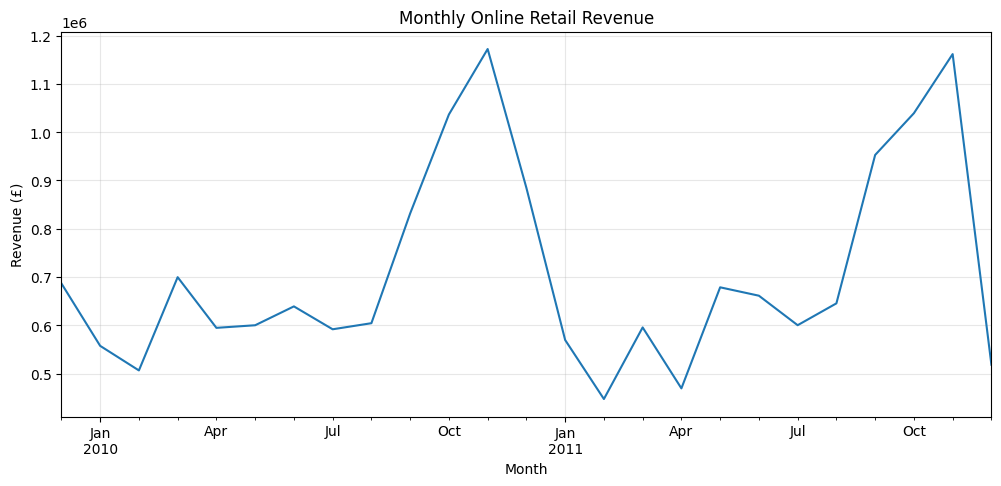

In [17]:
temporary_valid_sales = df_raw[
    df_raw["CustomerID"].notna()
    & ~df_raw["IsCancellation"]
    & (df_raw["Quantity"] > 0)
    & (df_raw["UnitPrice"] > 0)
].copy()

temporary_valid_sales["Revenue"] = (
    temporary_valid_sales["Quantity"]
    * temporary_valid_sales["UnitPrice"]
)

temporary_valid_sales["Month"] = (
    temporary_valid_sales["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_revenue = (
    temporary_valid_sales
    .groupby("Month")["Revenue"]
    .sum()
)

plt.figure(figsize=(12, 5))
monthly_revenue.plot()
plt.title("Monthly Online Retail Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(alpha=0.3)
plt.show()

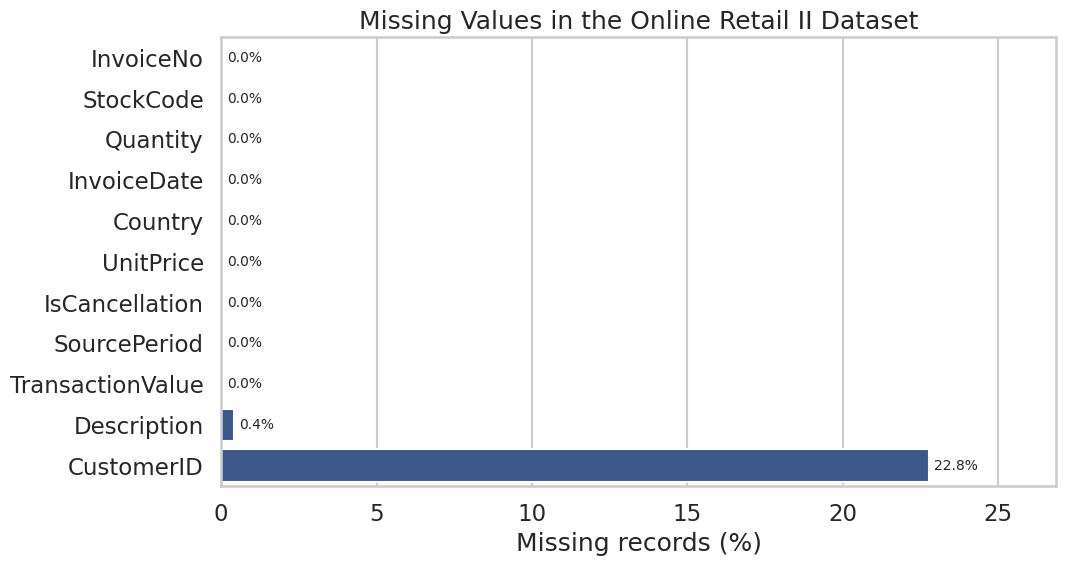

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

missing = pd.DataFrame({
    "Variable": df_raw.columns,
    "Missing_Count": df_raw.isna().sum().values,
    "Missing_Percentage": df_raw.isna().mean().values * 100
})

missing = missing.sort_values(
    "Missing_Percentage",
    ascending=True
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=missing,
    x="Missing_Percentage",
    y="Variable",
    color="#2F5597"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=10
    )

plt.title("Missing Values in the Online Retail II Dataset")
plt.xlabel("Missing records (%)")
plt.ylabel("")
plt.xlim(0, max(missing["Missing_Percentage"]) * 1.18)
plt.tight_layout()

plt.savefig(
    "figures/01_missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
invoice_customer_check = (
    df_raw
    .groupby(["SourcePeriod", "InvoiceNo"])
    .agg(
        Rows=("CustomerID", "size"),
        Known_IDs=("CustomerID", "nunique"),
        Missing_IDs=("CustomerID", lambda x: x.isna().sum())
    )
    .reset_index()
)

recoverable_invoices = invoice_customer_check[
    (invoice_customer_check["Known_IDs"] == 1)
    & (invoice_customer_check["Missing_IDs"] > 0)
]

print("Potentially recoverable invoices:", len(recoverable_invoices))
recoverable_invoices.head()

Potentially recoverable invoices: 0


,SourcePeriod,InvoiceNo,Rows,Known_IDs,Missing_IDs


In [20]:
cleaning_log = []

def record_stage(stage, dataframe):
    cleaning_log.append({
        "Stage": stage,
        "Rows": len(dataframe),
        "Rows_Removed_From_Original": len(df_raw) - len(dataframe),
        "Percentage_Retained": len(dataframe) / len(df_raw) * 100
    })

record_stage("Original dataset", df_raw)

In [21]:
df_cleaning = df_raw.copy()

duplicate_count = df_cleaning.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)

df_cleaning = df_cleaning.drop_duplicates().copy()

record_stage("After removing duplicates", df_cleaning)

Exact duplicate rows: 12133


In [22]:
missing_customer_rows = df_cleaning["CustomerID"].isna().sum()

print("Rows without CustomerID:", missing_customer_rows)
print(
    "Percentage without CustomerID:",
    missing_customer_rows / len(df_cleaning) * 100
)

df_customer = (
    df_cleaning
    .dropna(subset=["CustomerID"])
    .copy()
)

df_customer["CustomerID"] = (
    df_customer["CustomerID"]
    .astype("int64")
    .astype(str)
)

record_stage("Identifiable customers", df_customer)

Rows without CustomerID: 242870
Percentage without CustomerID: 23.015660921991056


In [23]:
df_customer["InvoiceNo"] = (
    df_customer["InvoiceNo"]
    .astype(str)
    .str.strip()
)

df_customer["StockCode"] = (
    df_customer["StockCode"]
    .astype(str)
    .str.strip()
)

df_customer["InvoiceDate"] = pd.to_datetime(
    df_customer["InvoiceDate"],
    errors="coerce"
)

df_customer["Quantity"] = pd.to_numeric(
    df_customer["Quantity"],
    errors="coerce"
)

df_customer["UnitPrice"] = pd.to_numeric(
    df_customer["UnitPrice"],
    errors="coerce"
)

In [24]:
df_customer[
    ["InvoiceDate", "Quantity", "UnitPrice"]
].isna().sum()

,0
InvoiceDate,0
Quantity,0
UnitPrice,0


In [25]:
df_customer["IsCancellation"] = (
    df_customer["InvoiceNo"]
    .str.upper()
    .str.startswith("C")
)

df_customer["IsNegativeQuantity"] = (
    df_customer["Quantity"] < 0
)

df_customer["IsReturn"] = (
    df_customer["IsCancellation"]
    | df_customer["IsNegativeQuantity"]
)

df_customer["TransactionValue"] = (
    df_customer["Quantity"]
    * df_customer["UnitPrice"]
)

In [26]:
df_purchases = df_customer[
    (~df_customer["IsReturn"])
    & (df_customer["Quantity"] > 0)
    & (df_customer["UnitPrice"] > 0)
    & (df_customer["InvoiceDate"].notna())
].copy()

df_purchases["Revenue"] = (
    df_purchases["Quantity"]
    * df_purchases["UnitPrice"]
)

record_stage("Valid positive purchases", df_purchases)

In [27]:
df_returns = df_customer[
    df_customer["IsReturn"]
    & (df_customer["UnitPrice"] > 0)
].copy()

df_returns["ReturnValue"] = (
    df_returns["Quantity"].abs()
    * df_returns["UnitPrice"]
)

print("Purchase rows:", len(df_purchases))
print("Return or cancellation rows:", len(df_returns))

Purchase rows: 793609
Return or cancellation rows: 18688


In [28]:
cleaning_summary = pd.DataFrame(cleaning_log)

cleaning_summary

,Stage,Rows,Rows_Removed_From_Original,Percentage_Retained
0,Original dataset,1067371,0,100.000000
1,After removing duplicates,1055238,12133,98.863282
2,Identifiable customers,812368,255003,76.109244
3,Valid positive purchases,793609,273762,74.351748


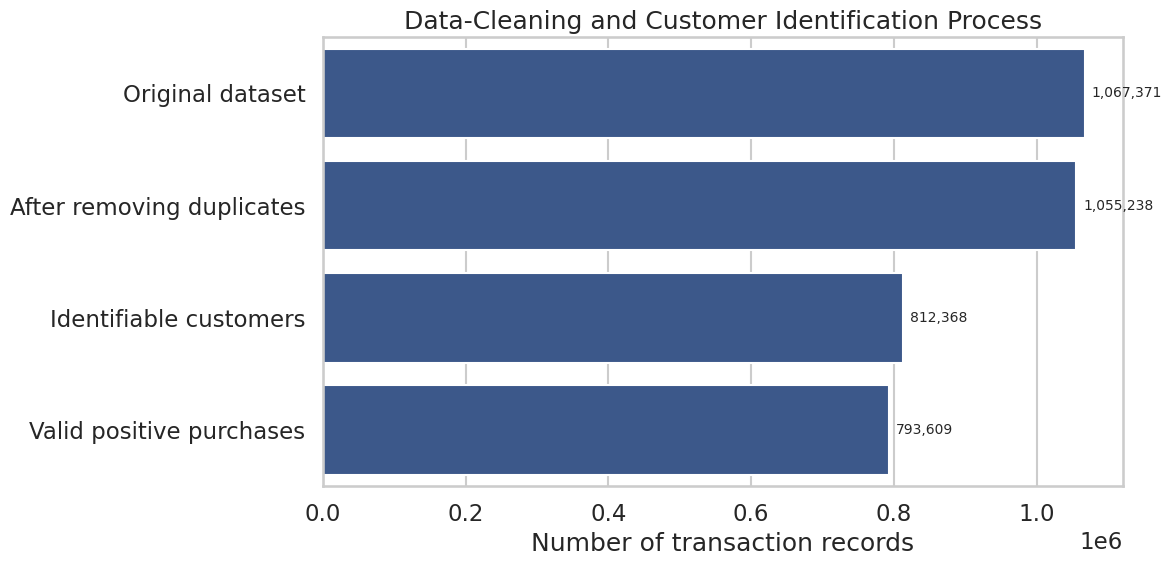

In [29]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=cleaning_summary,
    x="Rows",
    y="Stage",
    color="#2F5597"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="{:,.0f}",
        padding=5,
        fontsize=10
    )

plt.title("Data-Cleaning and Customer Identification Process")
plt.xlabel("Number of transaction records")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    "figures/02_data_cleaning_flow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
year1_purchases = df_purchases[
    df_purchases["SourcePeriod"] == "2009-2010"
].copy()

year2_purchases = df_purchases[
    df_purchases["SourcePeriod"] == "2010-2011"
].copy()

year1_returns = df_returns[
    df_returns["SourcePeriod"] == "2009-2010"
].copy()

year2_returns = df_returns[
    df_returns["SourcePeriod"] == "2010-2011"
].copy()

print("Year 1 purchase rows:", len(year1_purchases))
print("Year 2 purchase rows:", len(year2_purchases))

print(
    "Year 1 customers:",
    year1_purchases["CustomerID"].nunique()
)

print(
    "Year 2 customers:",
    year2_purchases["CustomerID"].nunique()
)

Year 1 purchase rows: 400916
Year 2 purchase rows: 392693
Year 1 customers: 4312
Year 2 customers: 4338


In [31]:
year1_customers = set(year1_purchases["CustomerID"])
year2_customers = set(year2_purchases["CustomerID"])

returning_customers = year1_customers.intersection(
    year2_customers
)

new_year2_customers = year2_customers.difference(
    year1_customers
)

print("Customers in Year 1:", len(year1_customers))
print("Customers returning in Year 2:", len(returning_customers))
print("New customers in Year 2:", len(new_year2_customers))

print(
    "Observed repeat-purchase rate:",
    len(returning_customers) / len(year1_customers)
)

Customers in Year 1: 4312
Customers returning in Year 2: 2772
New customers in Year 2: 1566
Observed repeat-purchase rate: 0.6428571428571429


In [32]:
deduplication_columns = [
    column for column in df_raw.columns
    if column != "SourcePeriod"
]

df_cleaning = df_raw.drop_duplicates(
    subset=deduplication_columns
).copy()

print("Original rows:", len(df_raw))
print("Rows after removing cross-sheet duplicates:", len(df_cleaning))
print("Rows removed:", len(df_raw) - len(df_cleaning))

Original rows: 1067371
Rows after removing cross-sheet duplicates: 1033036
Rows removed: 34335


In [33]:
df_customer = (
    df_cleaning
    .dropna(subset=["CustomerID"])
    .copy()
)

df_customer["CustomerID"] = (
    df_customer["CustomerID"]
    .astype("int64")
    .astype(str)
)

df_customer["InvoiceNo"] = (
    df_customer["InvoiceNo"]
    .astype(str)
    .str.strip()
)

df_customer["StockCode"] = (
    df_customer["StockCode"]
    .astype(str)
    .str.strip()
)

df_customer["InvoiceDate"] = pd.to_datetime(
    df_customer["InvoiceDate"],
    errors="coerce"
)

df_customer["Quantity"] = pd.to_numeric(
    df_customer["Quantity"],
    errors="coerce"
)

df_customer["UnitPrice"] = pd.to_numeric(
    df_customer["UnitPrice"],
    errors="coerce"
)

df_customer["IsCancellation"] = (
    df_customer["InvoiceNo"]
    .str.upper()
    .str.startswith("C")
)

df_customer["IsReturn"] = (
    df_customer["IsCancellation"]
    | (df_customer["Quantity"] < 0)
)

df_customer["TransactionValue"] = (
    df_customer["Quantity"]
    * df_customer["UnitPrice"]
)

In [34]:
df_purchases = df_customer[
    (~df_customer["IsReturn"])
    & (df_customer["Quantity"] > 0)
    & (df_customer["UnitPrice"] > 0)
    & (df_customer["InvoiceDate"].notna())
].copy()

df_purchases["Revenue"] = (
    df_purchases["Quantity"]
    * df_purchases["UnitPrice"]
)

df_returns = df_customer[
    df_customer["IsReturn"]
    & (df_customer["UnitPrice"] > 0)
    & (df_customer["InvoiceDate"].notna())
].copy()

df_returns["ReturnValue"] = (
    df_returns["Quantity"].abs()
    * df_returns["UnitPrice"]
)

In [35]:
cutoff_date = pd.Timestamp("2010-12-01")

In [36]:
observation_purchases = df_purchases[
    df_purchases["InvoiceDate"] < cutoff_date
].copy()

future_purchases = df_purchases[
    df_purchases["InvoiceDate"] >= cutoff_date
].copy()

observation_returns = df_returns[
    df_returns["InvoiceDate"] < cutoff_date
].copy()

future_returns = df_returns[
    df_returns["InvoiceDate"] >= cutoff_date
].copy()

print(
    "Observation period:",
    observation_purchases["InvoiceDate"].min(),
    "to",
    observation_purchases["InvoiceDate"].max()
)

print(
    "Future period:",
    future_purchases["InvoiceDate"].min(),
    "to",
    future_purchases["InvoiceDate"].max()
)

Observation period: 2009-12-01 07:45:00 to 2010-11-30 19:35:00
Future period: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [37]:
observation_orders = (
    observation_purchases
    .groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        OrderDate=("InvoiceDate", "min"),
        OrderRevenue=("Revenue", "sum"),
        OrderQuantity=("Quantity", "sum"),
        ProductsInOrder=("StockCode", "nunique")
    )
)

print("Observation-period orders:", len(observation_orders))
observation_orders.head()

Observation-period orders: 18437


,CustomerID,InvoiceNo,OrderDate,OrderRevenue,OrderQuantity,ProductsInOrder
0,12346,491725,2009-12-14 08:34:00,45.0,10,1
1,12346,491742,2009-12-14 11:00:00,22.5,5,1
2,12346,491744,2009-12-14 11:02:00,22.5,5,1
3,12346,492718,2009-12-18 10:47:00,22.5,5,1
4,12346,492722,2009-12-18 10:55:00,1.0,1,1


In [38]:
customer_features = (
    observation_orders
    .groupby("CustomerID")
    .agg(
        Frequency=("InvoiceNo", "nunique"),
        MonetaryValue=("OrderRevenue", "sum"),
        AverageOrderValue=("OrderRevenue", "mean"),
        StdOrderValue=("OrderRevenue", "std"),
        MaximumOrderValue=("OrderRevenue", "max"),
        TotalQuantity=("OrderQuantity", "sum"),
        AverageBasketQuantity=("OrderQuantity", "mean"),
        AverageProductsPerOrder=("ProductsInOrder", "mean"),
        FirstPurchase=("OrderDate", "min"),
        LastPurchase=("OrderDate", "max")
    )
    .reset_index()
)

customer_features["RecencyDays"] = (
    cutoff_date - customer_features["LastPurchase"]
).dt.days

customer_features["CustomerTenureDays"] = (
    customer_features["LastPurchase"]
    - customer_features["FirstPurchase"]
).dt.days + 1

customer_features["StdOrderValue"] = (
    customer_features["StdOrderValue"]
    .fillna(0)
)

In [39]:
observation_purchases["PurchaseMonth"] = (
    observation_purchases["InvoiceDate"]
    .dt.to_period("M")
)

additional_features = (
    observation_purchases
    .groupby("CustomerID")
    .agg(
        ProductDiversity=("StockCode", "nunique"),
        ActiveMonths=("PurchaseMonth", "nunique"),
        PurchaseDays=("InvoiceDate", lambda x: x.dt.date.nunique())
    )
    .reset_index()
)

customer_features = customer_features.merge(
    additional_features,
    on="CustomerID",
    how="left"
)

In [40]:
observation_orders = observation_orders.sort_values(
    ["CustomerID", "OrderDate"]
)

observation_orders["PreviousOrderDate"] = (
    observation_orders
    .groupby("CustomerID")["OrderDate"]
    .shift(1)
)

observation_orders["DaysBetweenOrders"] = (
    observation_orders["OrderDate"]
    - observation_orders["PreviousOrderDate"]
).dt.total_seconds() / 86400

interpurchase_features = (
    observation_orders
    .groupby("CustomerID")["DaysBetweenOrders"]
    .agg(
        AverageDaysBetweenOrders="mean",
        StdDaysBetweenOrders="std"
    )
    .reset_index()
)

customer_features = customer_features.merge(
    interpurchase_features,
    on="CustomerID",
    how="left"
)

customer_features[
    ["AverageDaysBetweenOrders", "StdDaysBetweenOrders"]
] = customer_features[
    ["AverageDaysBetweenOrders", "StdDaysBetweenOrders"]
].fillna(0)

In [41]:
customer_country = (
    observation_purchases
    .groupby("CustomerID")["Country"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)

customer_country = customer_country.rename(
    columns={"Country": "PrimaryCountry"}
)

customer_country["IsUK"] = (
    customer_country["PrimaryCountry"]
    == "United Kingdom"
).astype(int)

customer_features = customer_features.merge(
    customer_country,
    on="CustomerID",
    how="left"
)

In [42]:
historical_return_features = (
    observation_returns
    .groupby("CustomerID")
    .agg(
        ReturnInvoiceCount=("InvoiceNo", "nunique"),
        ReturnLineCount=("InvoiceNo", "size"),
        HistoricalReturnValue=("ReturnValue", "sum")
    )
    .reset_index()
)

customer_features = customer_features.merge(
    historical_return_features,
    on="CustomerID",
    how="left"
)

return_columns = [
    "ReturnInvoiceCount",
    "ReturnLineCount",
    "HistoricalReturnValue"
]

customer_features[return_columns] = (
    customer_features[return_columns]
    .fillna(0)
)

customer_features["ReturnInvoiceRate"] = (
    customer_features["ReturnInvoiceCount"]
    /
    (
        customer_features["Frequency"]
        + customer_features["ReturnInvoiceCount"]
    )
)

In [43]:
future_orders = (
    future_purchases
    .groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        OrderDate=("InvoiceDate", "min"),
        OrderRevenue=("Revenue", "sum")
    )
)

In [44]:
future_targets = (
    future_orders
    .groupby("CustomerID")
    .agg(
        FuturePurchaseCount=("InvoiceNo", "nunique"),
        FutureGrossRevenue=("OrderRevenue", "sum"),
        FutureAverageOrderValue=("OrderRevenue", "mean")
    )
    .reset_index()
)

In [45]:
future_return_targets = (
    future_returns
    .groupby("CustomerID")
    .agg(
        FutureReturnCount=("InvoiceNo", "nunique"),
        FutureReturnValue=("ReturnValue", "sum")
    )
    .reset_index()
)

In [46]:
customer_model = customer_features.merge(
    future_targets,
    on="CustomerID",
    how="left"
)

customer_model = customer_model.merge(
    future_return_targets,
    on="CustomerID",
    how="left"
)

In [47]:
future_columns = [
    "FuturePurchaseCount",
    "FutureGrossRevenue",
    "FutureAverageOrderValue",
    "FutureReturnCount",
    "FutureReturnValue"
]

customer_model[future_columns] = (
    customer_model[future_columns]
    .fillna(0)
)

customer_model["RepeatPurchase"] = (
    customer_model["FuturePurchaseCount"] > 0
).astype(int)

customer_model["FutureNetRevenue"] = (
    customer_model["FutureGrossRevenue"]
    - customer_model["FutureReturnValue"]
)

customer_model["FutureNetRevenueNonnegative"] = (
    customer_model["FutureNetRevenue"]
    .clip(lower=0)
)

In [48]:
print("Customer-level dataset shape:", customer_model.shape)

print("\nRepeat-purchase distribution:")
print(
    customer_model["RepeatPurchase"]
    .value_counts()
)

print("\nRepeat-purchase percentages:")
print(
    customer_model["RepeatPurchase"]
    .value_counts(normalize=True)
    .mul(100)
)

customer_model.describe().T

Customer-level dataset shape: (4266, 32)

Repeat-purchase distribution:
RepeatPurchase
1    2726
0    1540
Name: count, dtype: int64

Repeat-purchase percentages:
RepeatPurchase
1    63.900609
0    36.099391
Name: proportion, dtype: float64


,count,mean,min,25%,50%,75%,max,std
Frequency,4266.0,4.321847,1.0,1.0,2.0,5.0,197.0,7.763641
MonetaryValue,4266.0,1989.58682,2.95,306.595,681.81,1662.2225,321329.74,8599.149266
AverageOrderValue,4266.0,379.687099,2.95,179.0275,288.20875,424.0075,11880.84,506.279065
StdOrderValue,4266.0,146.259472,0.0,0.0,64.568262,167.470793,13108.02995,402.303947
MaximumOrderValue,4266.0,608.925703,2.95,224.8125,369.65,624.2825,44051.6,1351.795567
TotalQuantity,4266.0,1256.903188,1.0,156.0,378.0,973.75,220600.0,6402.325179
AverageBasketQuantity,4266.0,257.084034,1.0,89.020833,154.0,258.0,87167.0,1562.72709
AverageProductsPerOrder,4266.0,21.428466,1.0,9.88244,17.5,27.0,220.0,17.884598
FirstPurchase,4266,2010-04-26 16:28:58.410689280,2009-12-01 07:45:00,2010-01-14 11:00:00,2010-03-30 17:09:00,2010-08-09 10:05:00,2010-11-30 18:46:00,NaN
LastPurchase,4266,2010-09-04 07:55:20.267229440,2009-12-01 09:55:00,2010-07-19 13:35:30,2010-10-14 10:05:00,2010-11-15 11:25:45,2010-11-30 19:35:00,NaN


In [49]:
assert customer_model["CustomerID"].is_unique
assert customer_model["CustomerID"].notna().all()

print("Customer-level validation passed.")

Customer-level validation passed.


In [50]:
from pathlib import Path

Path("data/processed").mkdir(
    parents=True,
    exist_ok=True
)

customer_model.to_csv(
    "data/processed/customer_clv_model.csv",
    index=False
)

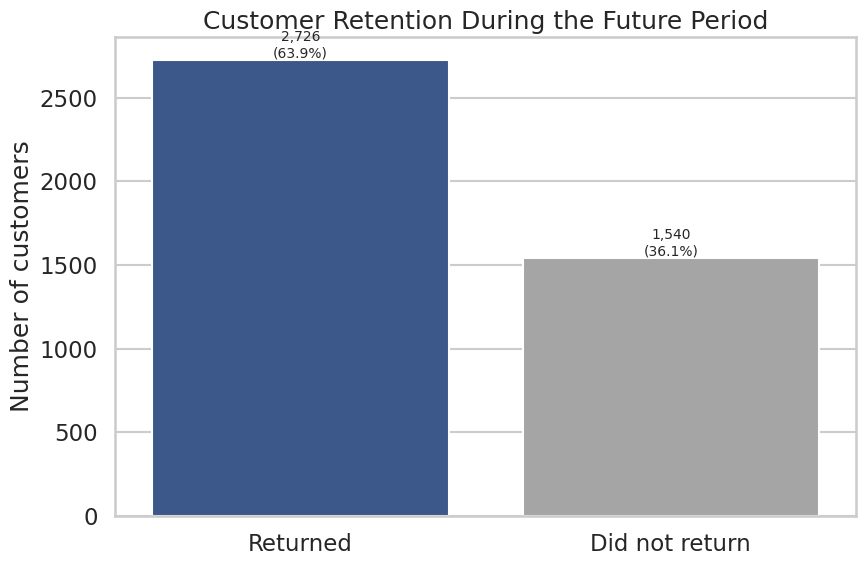

In [51]:
repeat_summary = (
    customer_model["RepeatPurchase"]
    .value_counts()
    .rename(index={
        0: "Did not return",
        1: "Returned"
    })
    .reset_index()
)

repeat_summary.columns = [
    "CustomerOutcome",
    "Customers"
]

repeat_summary["Percentage"] = (
    repeat_summary["Customers"]
    / repeat_summary["Customers"].sum()
    * 100
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=repeat_summary,
    x="CustomerOutcome",
    y="Customers",
    hue="CustomerOutcome",
    palette={
        "Did not return": "#A5A5A5",
        "Returned": "#2F5597"
    },
    legend=False
)

for index, row in repeat_summary.iterrows():
    ax.text(
        index,
        row["Customers"],
        f'{row["Customers"]:,.0f}\n({row["Percentage"]:.1f}%)',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Customer Retention During the Future Period")
plt.xlabel("")
plt.ylabel("Number of customers")
plt.tight_layout()

plt.savefig(
    "figures/03_repeat_purchase_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

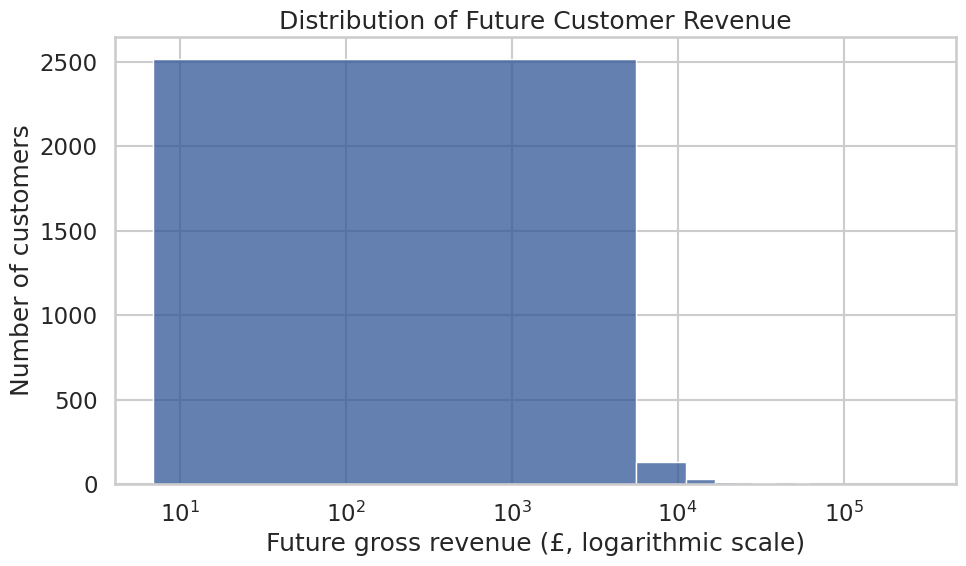

In [52]:
positive_future_revenue = customer_model[
    customer_model["FutureGrossRevenue"] > 0
].copy()

plt.figure(figsize=(10, 6))

sns.histplot(
    data=positive_future_revenue,
    x="FutureGrossRevenue",
    bins=50,
    color="#2F5597"
)

plt.xscale("log")
plt.title("Distribution of Future Customer Revenue")
plt.xlabel("Future gross revenue (£, logarithmic scale)")
plt.ylabel("Number of customers")
plt.tight_layout()

plt.savefig(
    "figures/04_future_revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
print("Dataset shape:", customer_model.shape)

print(
    "Repeat rate:",
    customer_model["RepeatPurchase"].mean()
)

print(
    "Median future revenue:",
    customer_model["FutureGrossRevenue"].median()
)

print(
    "Customers with positive future revenue:",
    (customer_model["FutureGrossRevenue"] > 0).sum()
)

Dataset shape: (4266, 32)
Repeat rate: 0.6390060947022972
Median future revenue: 314.875
Customers with positive future revenue: 2726


In [54]:
from pathlib import Path

Path("data/cleaned").mkdir(
    parents=True,
    exist_ok=True
)

df_purchases.to_csv(
    "data/cleaned/online_retail_purchases.csv",
    index=False
)

df_returns.to_csv(
    "data/cleaned/online_retail_returns.csv",
    index=False
)

In [55]:
cleaning_summary.to_csv(
    "data/cleaned/cleaning_summary.csv",
    index=False
)

In [56]:
quality_summary = pd.DataFrame({
    "Measure": [
        "Original rows",
        "Rows after duplicate removal",
        "Identified-customer rows",
        "Valid purchase rows",
        "Return or cancellation rows"
    ],
    "Count": [
        len(df_raw),
        len(df_cleaning),
        len(df_customer),
        len(df_purchases),
        len(df_returns)
    ]
})

quality_summary.to_csv(
    "data/cleaned/data_quality_summary.csv",
    index=False
)

quality_summary

,Measure,Count
0,Original rows,1067371
1,Rows after duplicate removal,1033036
2,Identified-customer rows,797885
3,Valid purchase rows,779425
4,Return or cancellation rows,18390
